In [ ]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/time_series_data_018.csv', index_col = 'Date', parse_dates = True, dayfirst = True)
df.head()

,Value
Date,
2021-01-01,1.000000
2021-01-02,0.901805
2021-01-03,1.104418
2021-01-04,1.056332
2021-01-05,0.957646


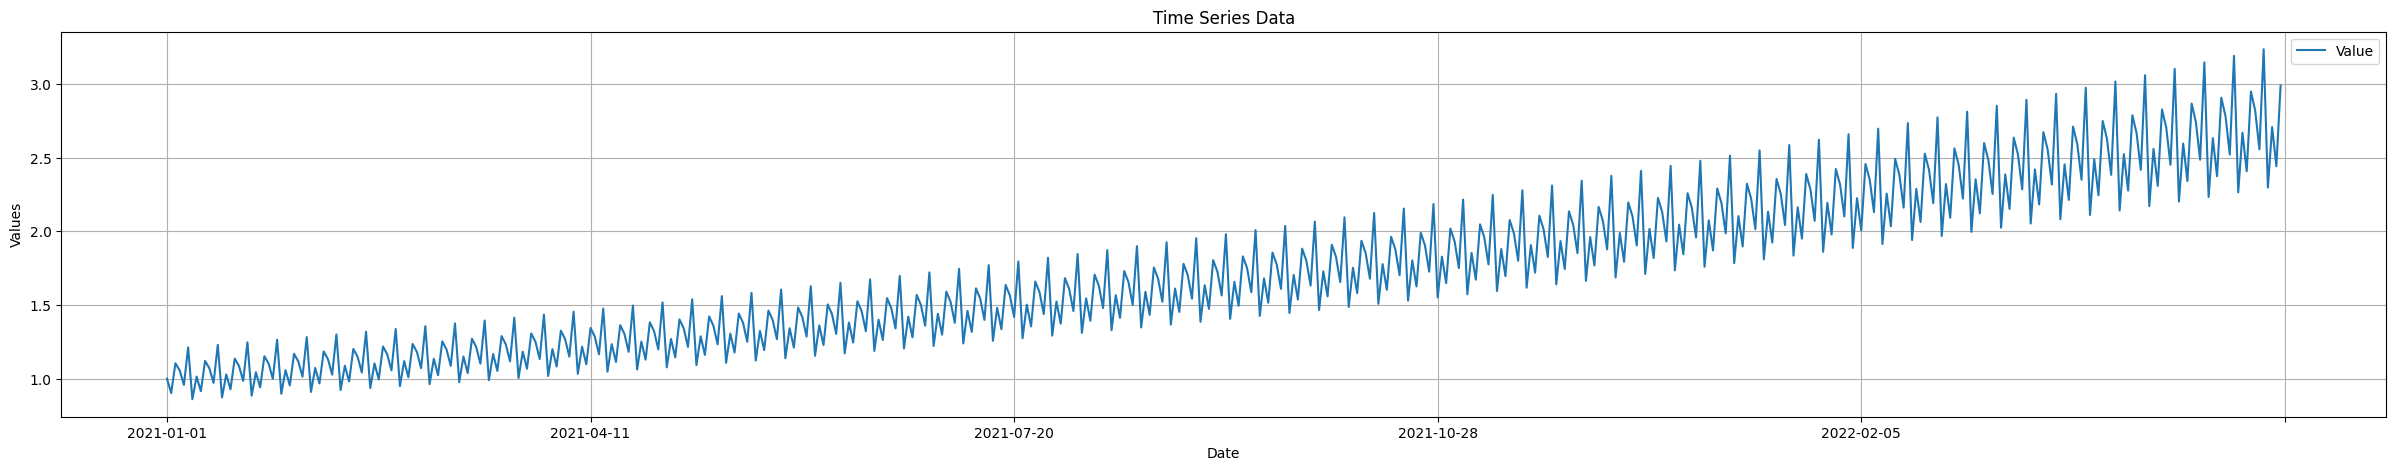

In [ ]:
df.plot(figsize = (30,5), grid = True, ylabel = 'Values', title = 'Time Series Data')
plt.show()


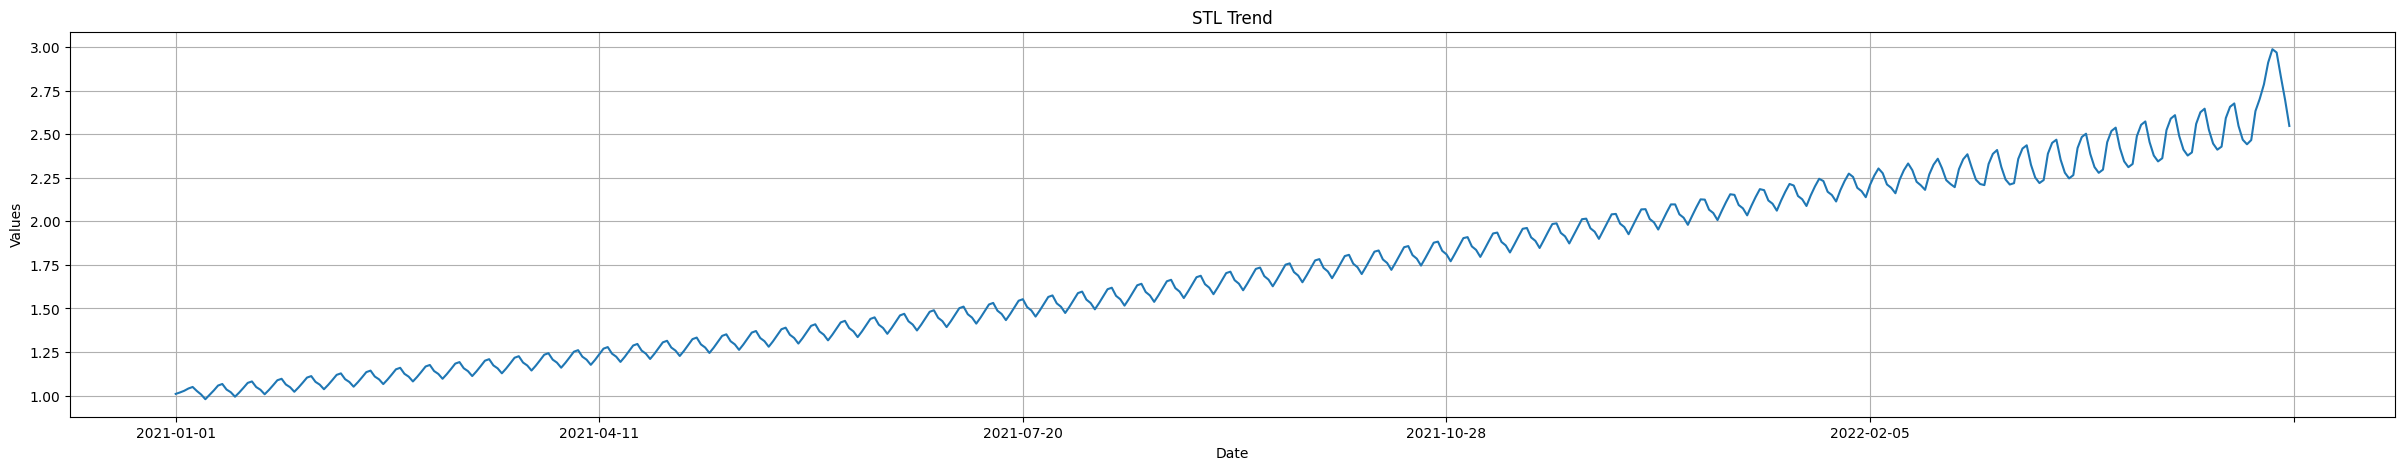

In [ ]:
# STL Trned
from statsmodels.tsa.seasonal import STL

df_stl = STL(df["Value"],period =3, robust = True)
decomp_stl = df_stl.fit()

decomp_stl.trend.plot(figsize = (30,5), grid = True, ylabel = 'Values', title = 'STL Trend')
plt.show()

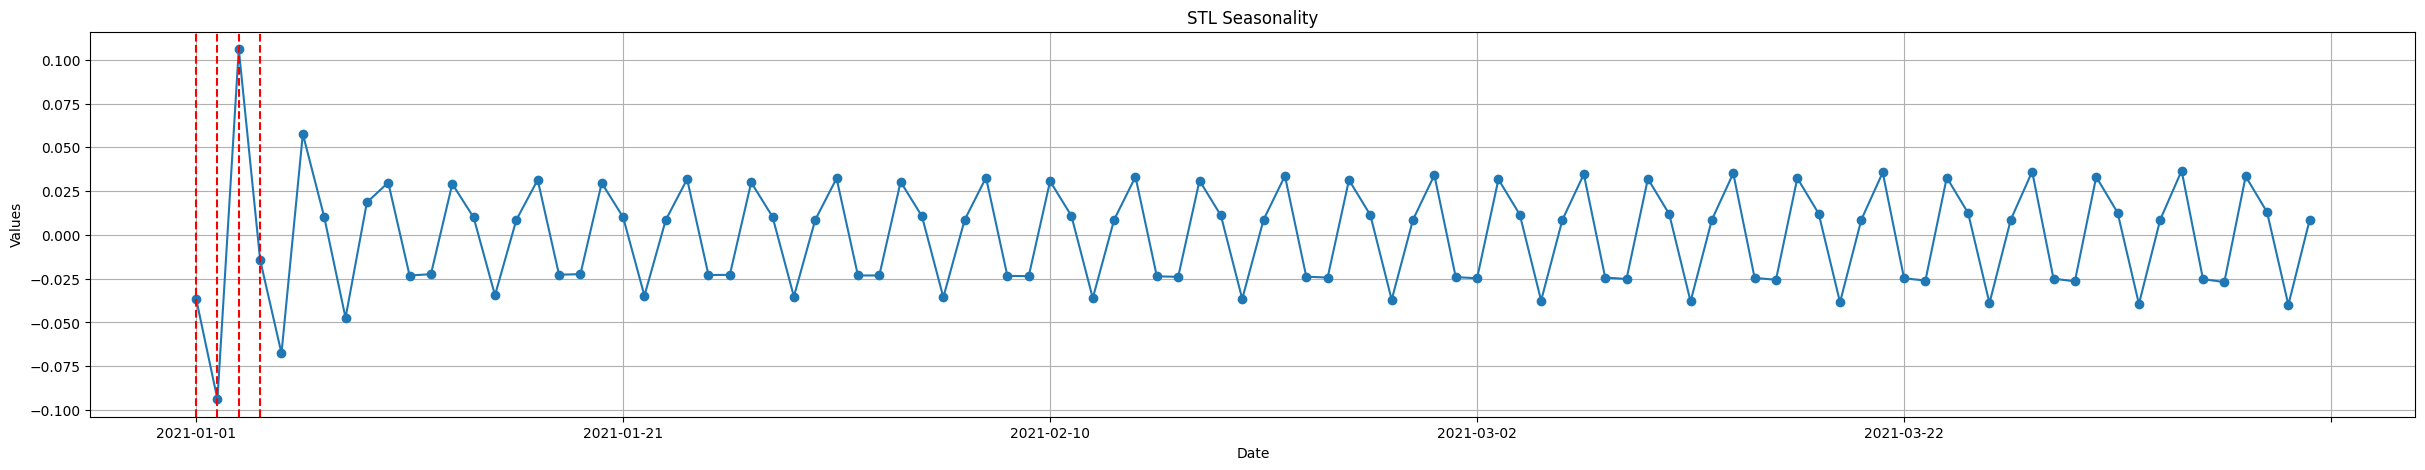

In [ ]:
# STL Seasonality

fig, ax = plt.subplots(figsize=(25, 4))
decomp_stl.seasonal[:100].plot(ax = ax, figsize = (30,5), grid = True, ylabel = 'Values', title = 'STL Seasonality', marker = 'o')

for day in range(0, 100, 30):

 ax.axvline(x = decomp_stl.seasonal.index[day], color = 'red', linestyle = '--')

plt.show()

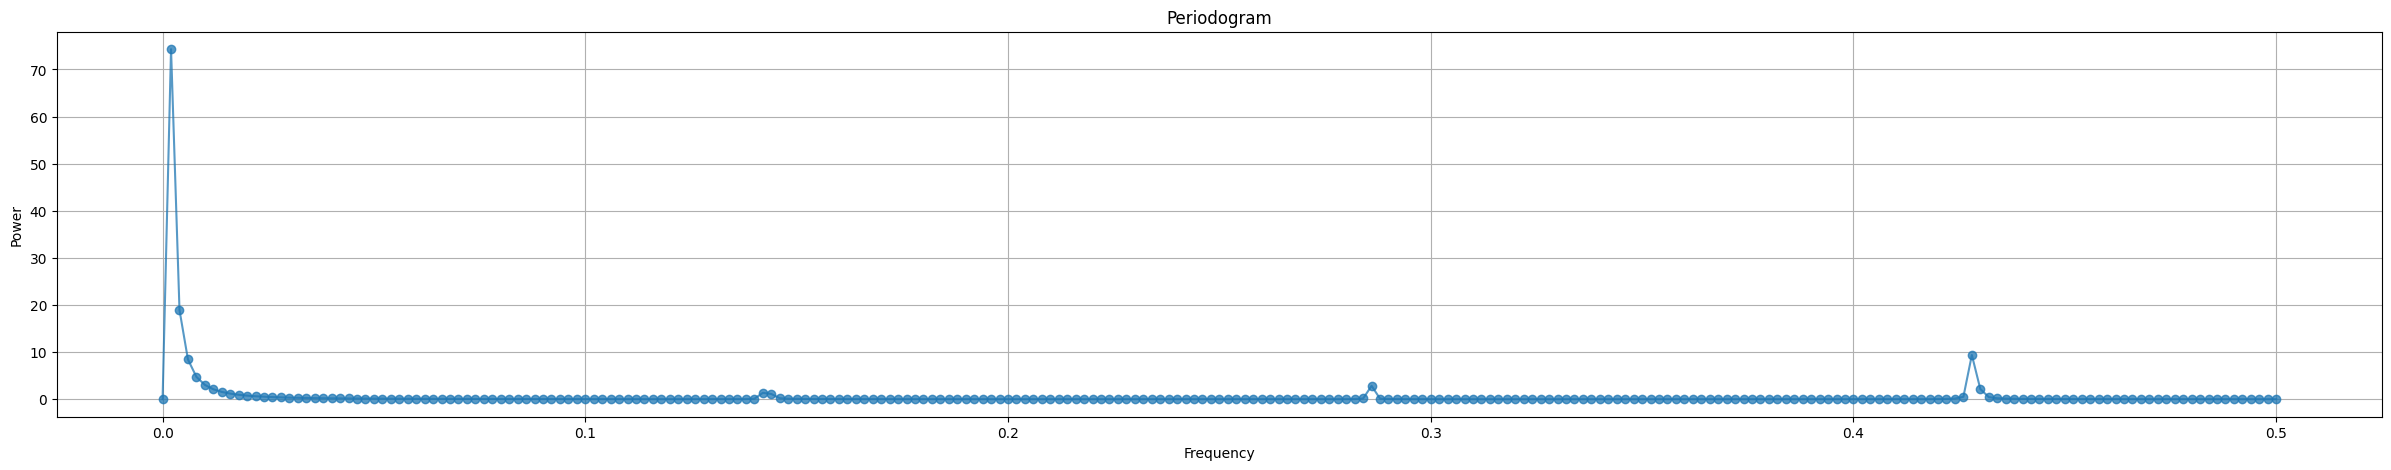

In [ ]:
# Periodogram (for Seasonality)

from scipy.signal import periodogram

frequencies, power = periodogram(df['Value'])

plt.figure(figsize=(30, 5))
plt.plot(frequencies, power, marker='o', linestyle='-', alpha = 0.75)
plt.title("Periodogram")
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.grid(True)
plt.show()

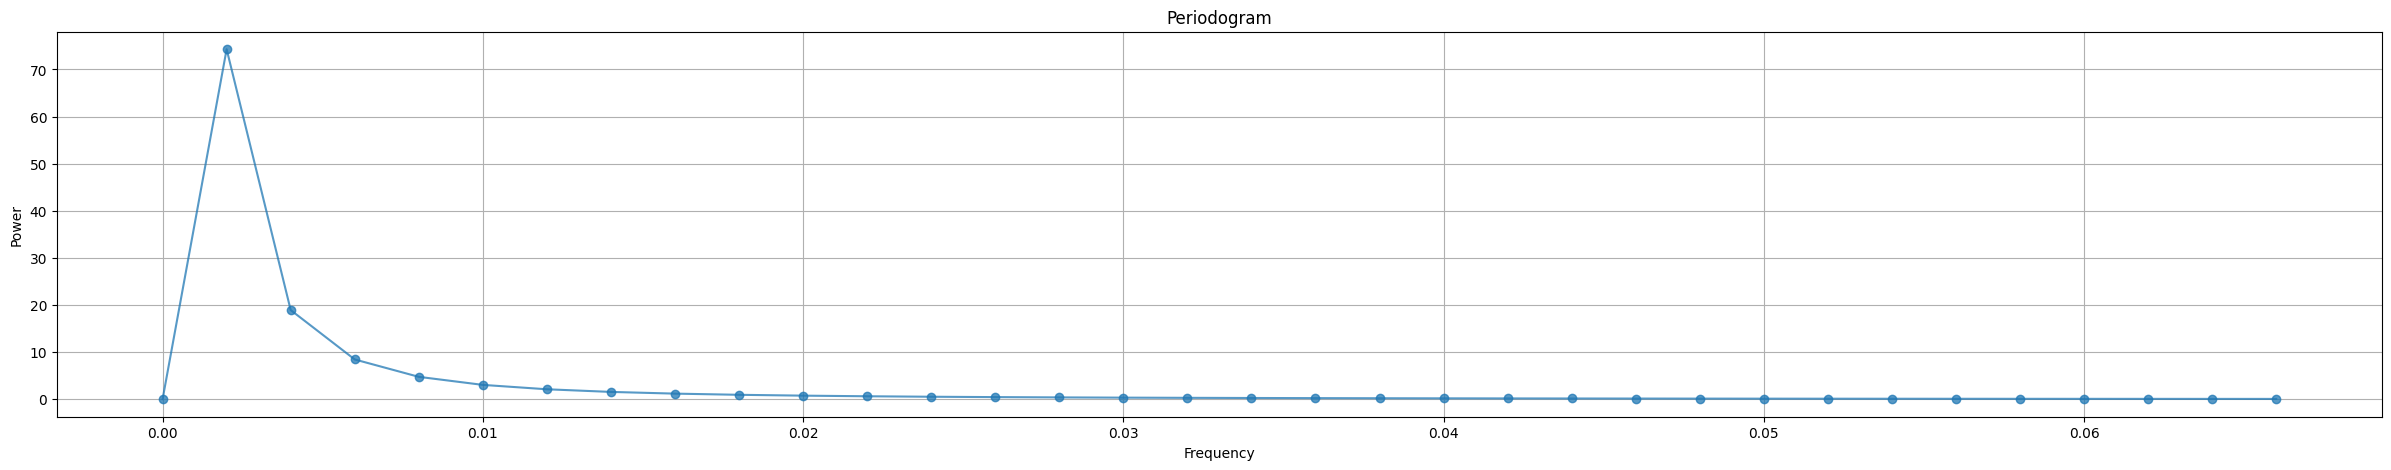

In [ ]:
# Periodogram of Seasonality

plt.figure(figsize=(30, 5))
plt.plot(frequencies[:34], power[:34], marker='o', linestyle='-', alpha = 0.75)
plt.title("Periodogram")
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.grid(True)
plt.show()

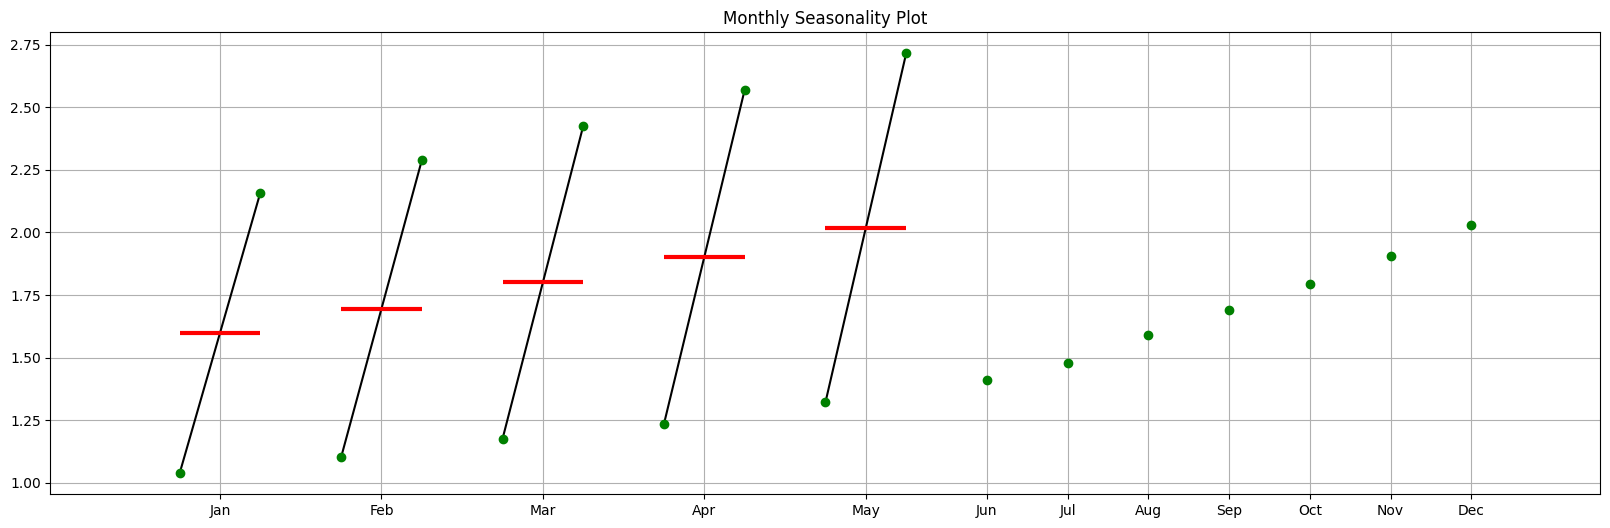

In [ ]:
from statsmodels.graphics.tsaplots import month_plot

df.index = pd.to_datetime(df.index)
ts_monthly = df['Value'].resample('MS').mean()

fig, ax = plt.subplots(figsize=(20, 6))
month_plot(ts_monthly, ax = ax)
plt.title("Monthly Seasonality Plot")
plt.grid()

for line in ax.get_lines():

  line.set_marker('o')
  line.set_markerfacecolor('green')
  line.set_markeredgecolor('green')

plt.show()

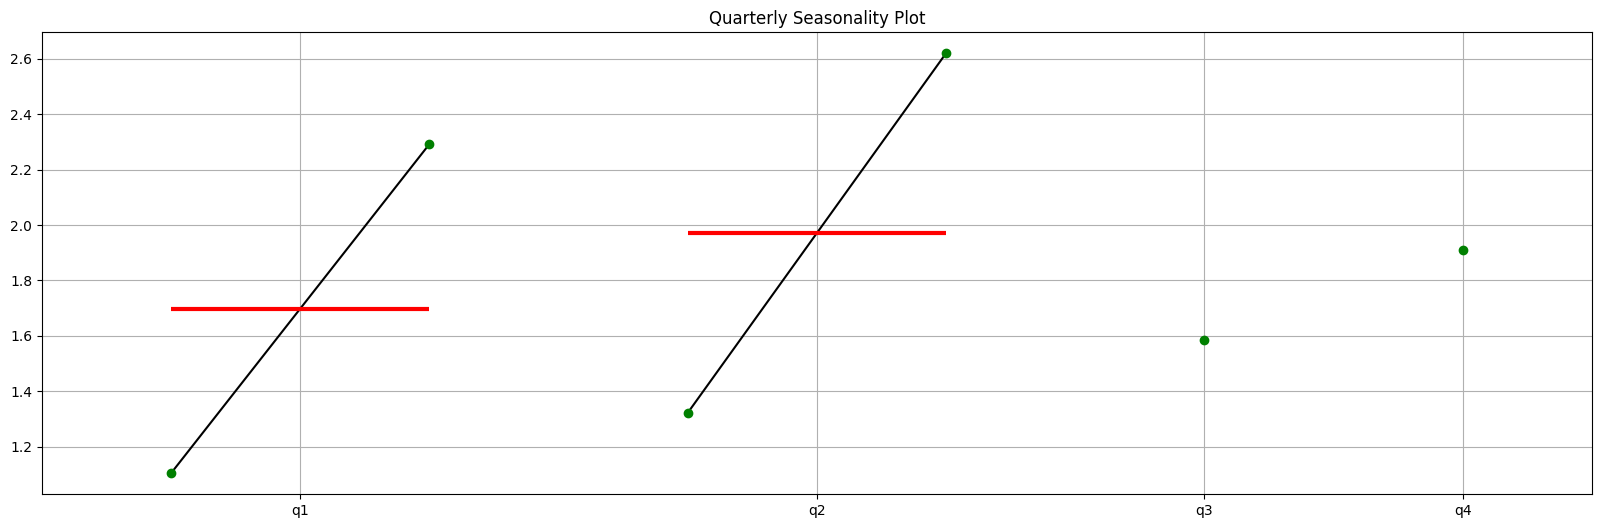

In [ ]:
# Quarter Plots

from statsmodels.graphics.tsaplots import quarter_plot

ts_quarter = df['Value'].resample('QE').mean()

fig, ax = plt.subplots(figsize=(20, 6))
quarter_plot(ts_quarter, ax = ax)
plt.title("Quarterly Seasonality Plot")
plt.grid()

for line in ax.get_lines():

  line.set_marker('o')
  line.set_markerfacecolor('green')
  line.set_markeredgecolor('green')

plt.show()

Week 7 Lab

Using Exponential Smoothing, answer the following

1. What is the best model for the time series data.
A. SES
B. DES
C. TES

Answer: TES Model

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

forecast_horizon = 3

train_data = df.iloc[:-forecast_horizon]
test_data = df.iloc[-forecast_horizon:]

train_data = train_data.asfreq('D')
test_data = test_data.asfreq('D')


tes_model = ExponentialSmoothing(train_data['Value'], trend = 'additive', seasonal = 'additive', seasonal_periods = 30).fit()

tes_pred = tes_model.forecast(forecast_horizon)
tes_pred

,0
2022-05-13,2.725040
2022-05-14,2.685786
2022-05-15,2.729895


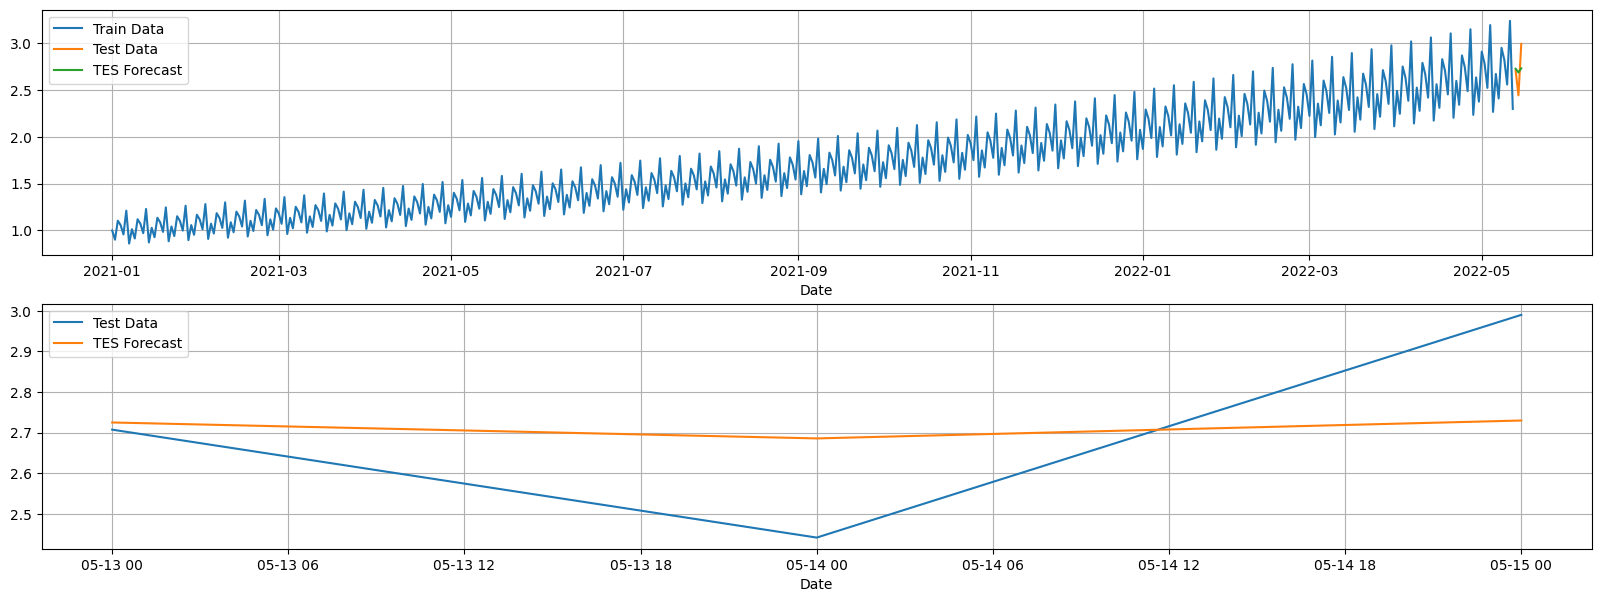

In [ ]:
plt.figure(figsize = (20, 7))

plt.subplot(2, 1, 1)
plt.plot(train_data.index, train_data['Value'], label = 'Train Data')
plt.plot(test_data.index, test_data['Value'], label = 'Test Data')
plt.plot(tes_pred.index, tes_pred, label = 'TES Forecast')
plt.legend()
plt.grid()
plt.xlabel('Date')

plt.subplot(2, 1, 2)
plt.plot(test_data.index, test_data['Value'], label = 'Test Data')
plt.plot(tes_pred.index, tes_pred, label = 'TES Forecast')
plt.legend()
plt.grid()
plt.xlabel('Date')
plt.show()

3. Using your best model, write the MAE, MSE, RMSE, and MAPE values.
MAE: 0.17402537302001905
MSE: 0.04255700879389152
RMSE: 0.2062935015794039
MAPE: 6.452263895632343

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test_data['Value'], tes_pred)
mse = mean_squared_error(test_data['Value'], tes_pred)
rmse = np.sqrt(mse)

mape = np.mean(np.abs((test_data['Value'] - tes_pred) / test_data['Value'])) * 100

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")


MAE: 0.17402537302001905
MSE: 0.04255700879389152
RMSE: 0.2062935015794039
MAPE: 6.452263895632343


4. Using your best model (at 30 days test set), what is the forecast at 2022-05-22?

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

df.index = pd.to_datetime(df.index)
df = df.asfreq('D')

last_date = df.index[-1]
target_date = pd.to_datetime("2022-05-22")
forecast_horizon = (target_date - last_date).days

model = ExponentialSmoothing(df['Value'], trend='additive', seasonal='additive', seasonal_periods=30).fit()

forecast = model.forecast(forecast_horizon)

forecast_value = forecast.loc[target_date]
print(f"Forecast for 2022-05-22: {forecast_value}")


Forecast for 2022-05-22: 2.7646253643148113


5. Using your best model (with forecast horizon of 30), what is the forecast at 2022-06-08?

In [ ]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

df.index = pd.to_datetime(df.index)
df = df.asfreq('D')

target_date = pd.to_datetime("2022-06-08")

last_date = df.index[-1]
forecast_horizon = (target_date - last_date).days

if forecast_horizon <= 0:
    print(f"Target date {target_date.date()} is within the dataset range. No forecast needed.")
else:

    model = ExponentialSmoothing(
        df['Value'],
        trend='additive',
        seasonal='additive',
        seasonal_periods=30
    ).fit()

    forecast = model.forecast(forecast_horizon)

    forecast_value = forecast.loc[target_date]
    print(f"Forecast for {target_date.date()}: {forecast_value:.2f}")


Forecast for 2022-06-08: 2.81


6. What is the best model for the same time series?
SARIMA

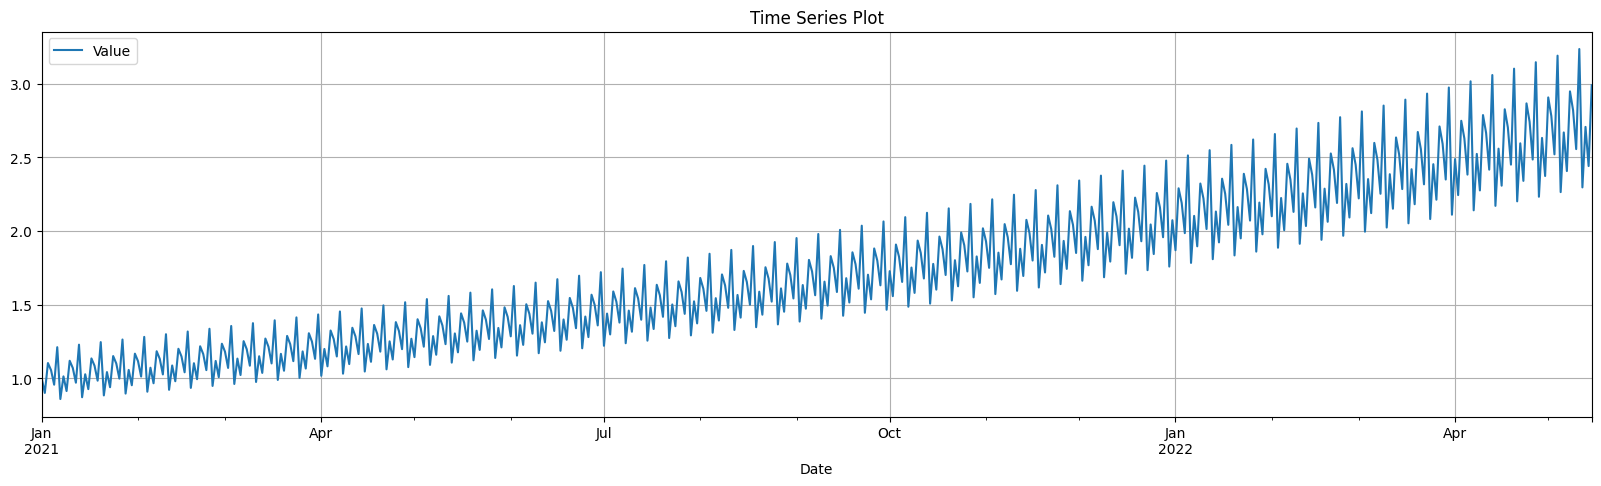

In [ ]:
#Looking for repeating pattern
df.plot(figsize=(20,5))
plt.title("Time Series Plot")
plt.grid()
plt.show()

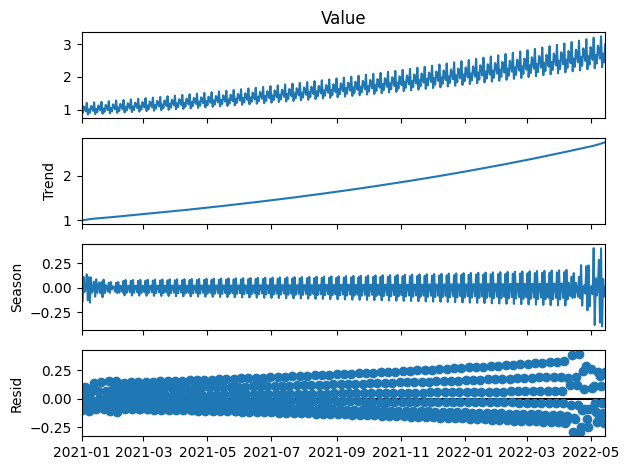

In [ ]:
from statsmodels.tsa.seasonal import STL
stl = STL(df['Value'], period=12)
res = stl.fit()
res.plot()
plt.show()

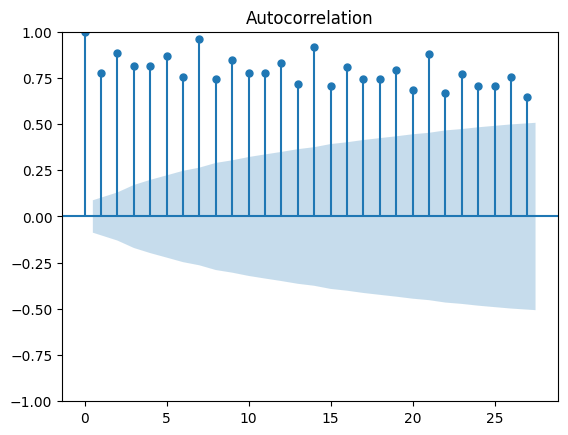

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df['Value'])
plt.show()

7. If ARIMA, write the best configuration, e.g. ARIMA(1,0,1)
   If SARIMA, write the best configuration, e.g. ARIMA(1,0,1)(1,0,1,[30])

In [ ]:
!pip install pmdarima

import pandas as pd
from pmdarima import auto_arima
import matplotlib.pyplot as plt

df = pd.read_csv(
    'https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/time_series_data_018.csv',
    index_col='Date',
    parse_dates=True,
    dayfirst=True
)

In [ ]:
test_days = 30
train, test = df.iloc[:-test_days], df.iloc[-test_days:]

In [ ]:
model = auto_arima(train['Value'], m = 7)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  470
Model:             SARIMAX(1, 1, 3)x(2, 1, [1], 7)   Log Likelihood                3661.666
Date:                             Thu, 10 Apr 2025   AIC                          -7307.332
Time:                                     05:12:21   BIC                          -7274.247
Sample:                                 01-01-2021   HQIC                         -7294.306
                                      - 04-15-2022                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9142      0.001   -679.313      0.000      -0.917      -0.912
ma.L1         -1.9030      0.006   -317.143      0.000      -1.915      -1.891
ma.L2          1.3718      0.006    230.988      0.000       1.360       1.383
ma.L3         -0.3743      0.004    -92.747      0.000      -0.382      -0.366
ar.S.L7        0.0530      0.000    122.999      0.000       0.052       0.054
ar.S.L14       0.9432      0.001   1594.202      0.000       0.942       0.944
ma.S.L7        0.8789      0.001   1350.870      0.000       0.878       0.880
sigma2      6.531e-09   7.64e-10      8.549      0.000    5.03e-09    8.03e-09
===================================================================================
Ljung-Box (L1) (Q):                 128.27   Jarque-Bera (JB):                 0.66
Prob(Q):                              0.00   Prob(JB):                         0.72
Heteroskedasticity (H):               2.32   Skew:                             0.04
Prob(H) (two-sided):                  0.00   Kurtosis:                         2.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 5.5e+18. Standard errors may be unstable.
"""

In [ ]:
stepwise_fit = auto_arima(train['Value'], seasonal = True, stepwise = True, trace = True, m = 7)


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[7]             : AIC=-6866.841, Time=5.55 sec
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=-3632.963, Time=0.14 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=-5016.325, Time=1.19 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=inf, Time=1.67 sec
 ARIMA(2,1,2)(0,1,1)[7]             : AIC=inf, Time=5.29 sec
 ARIMA(2,1,2)(1,1,0)[7]             : AIC=-5507.461, Time=4.23 sec
 ARIMA(2,1,2)(2,1,1)[7]             : AIC=-7277.980, Time=5.29 sec
 ARIMA(2,1,2)(2,1,0)[7]             : AIC=-5460.939, Time=3.20 sec
 ARIMA(2,1,2)(2,1,2)[7]             : AIC=inf, Time=nan sec
 ARIMA(2,1,2)(1,1,2)[7]             : AIC=-5978.790, Time=5.99 sec
 ARIMA(1,1,2)(2,1,1)[7]             : AIC=-6084.967, Time=6.07 sec
 ARIMA(2,1,1)(2,1,1)[7]             : AIC=-6319.213, Time=3.10 sec
 ARIMA(3,1,2)(2,1,1)[7]             : AIC=-6363.160, Time=5.57 sec
 ARIMA(2,1,3)(2,1,1)[7]             : AIC=inf, Time=6.81 sec
 ARIMA(1,1,1)(2,1,1)[7]             : AIC=-6

In [ ]:
predictions_sarima = model.predict(n_periods = len(test))
predictions_sarima

,0
2022-04-16,2.308466
2022-04-17,2.826826
2022-04-18,2.703901
2022-04-19,2.451236
2022-04-20,3.102475
2022-04-21,2.202085
2022-04-22,2.595877
2022-04-23,2.341221
2022-04-24,2.866624
2022-04-25,2.742066


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


mae = mean_absolute_error(test['Value'], predictions_sarima)
mse = mean_squared_error(test['Value'], predictions_sarima)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test['Value'] - predictions_sarima) / test['Value'])) * 100

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")


MAE: 0.0003179696477245179
MSE: 2.2484537485981465e-07
RMSE: 0.00047417863180431764
MAPE: nan


In [ ]:
import pandas as pd
df.index = pd.to_datetime(df.index)
df = df.asfreq('D')

last_date = df.index[-1]
target_date = pd.to_datetime("2022-05-22")
forecast_horizon = (target_date - last_date).days

model = ExponentialSmoothing(df['Value'], trend='additive', seasonal='additive', seasonal_periods=30).fit()

forecast = model.forecast(forecast_horizon)

forecast_value = forecast.loc[target_date]
print(f"Forecast for 2022-05-22: {forecast_value}")


Forecast for 2022-05-22: 2.7646253643148113


In [ ]:
import pandas as pd
df.index = pd.to_datetime(df.index)
df = df.asfreq('D')

target_date = pd.to_datetime("2022-06-08")

last_date = df.index[-1]
forecast_horizon = (target_date - last_date).days

if forecast_horizon <= 0:
    print(f"Target date {target_date.date()} is within the dataset range. No forecast needed.")
else:
    model = ExponentialSmoothing(
        df['Value'],
        trend='additive',
        seasonal='additive',
        seasonal_periods=30
    ).fit()

    forecast = model.forecast(forecast_horizon)

    forecast_value = forecast.loc[target_date]
    print(f"Forecast for {target_date.date()}: {forecast_value:.2f}")


Forecast for 2022-06-08: 2.81
